File downloaded from gs://ycbs299/master_merged_data.csv to /content/fire_incidents_caserne_month_aggregated.csv
Training set size: 13144 rows
Test set size: 1441 rows

Random Forest - Classification Report on 2023–2024 Test Set:
              precision    recall  f1-score   support

        High       0.50      0.71      0.59       356
         Low       0.81      0.61      0.70       719
      Medium       0.35      0.39      0.37       366

    accuracy                           0.58      1441
   macro avg       0.56      0.57      0.55      1441
weighted avg       0.62      0.58      0.59      1441


XGBoost - Classification Report on 2023–2024 Test Set:
              precision    recall  f1-score   support

        High       0.49      0.77      0.60       356
         Low       0.76      0.75      0.75       719
      Medium       0.40      0.19      0.25       366

    accuracy                           0.61      1441
   macro avg       0.55      0.57      0.54      1441
weighte

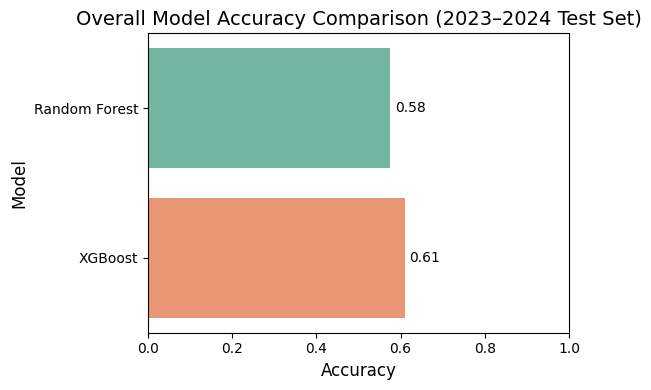


Model Parameters Table:
        Parameter Random Forest  XGBoost
     n_estimators           100         
        max_depth            30         
min_samples_split             2         
 min_samples_leaf             4         
     class_weight      balanced         
     random_state            42         
        subsample                    0.8
     n_estimators                    200
        max_depth                      3
    learning_rate                   0.05
 colsample_bytree                    0.8
      eval_metric               mlogloss
     random_state                     42


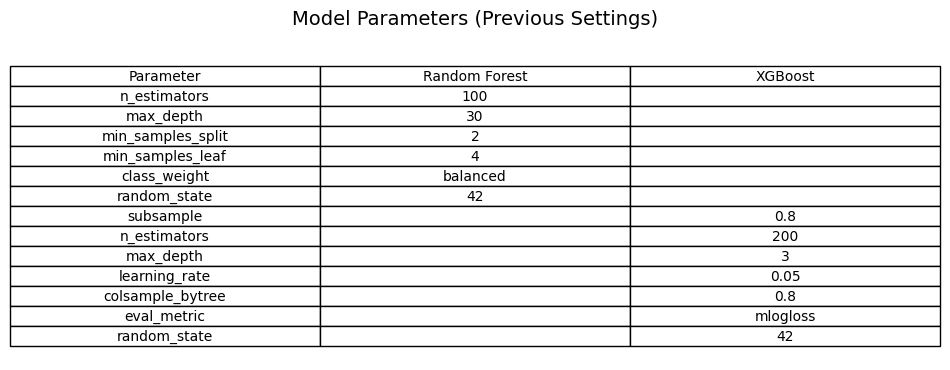

XGBoost Classifier trained on full dataset with previous parameters.
Future predictions saved to /content/future_predictions_2025_2026_previous_params.csv


<ipython-input-1-034fbc2ed7ce>:225: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_incidents = agg_df.groupby('risk_level')['incident_count'].median()
<ipython-input-1-034fbc2ed7ce>:225: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_incidents = agg_df.groupby('risk_level')['incident_count'].median()
<ipython-input-1-034fbc2ed7ce>:225: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_incidents = agg_df.gr

ServiceException: 401 Anonymous caller does not have storage.objects.list access to the Google Cloud Storage bucket. Permission 'storage.objects.list' denied on resource (or it may not exist).
Future predictions uploaded to gs://ycbs299/data/future_predictions_2025_2026_previous_params.csv

Sample of Future Predictions (March 2025 - February 2026):
   CASERNE  year  month predicted_risk_level  predicted_incident_count
0        3  2025      3                  Low                       3.0
1        4  2025      3                  Low                       3.0
2        5  2025      3                  Low                       3.0
3        8  2025      3                  Low                       3.0
4        9  2025      3                 High                      11.0
5       10  2025      3                  Low                       3.0
6       13  2025      3                  Low                       3.0
7       14  2025      3                  Low                       3.0
8       15

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.cloud import storage

# Step 1: Set Google Application Credentials
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '/content/peppy-web-437616-r6-ec3f12e7c15e.json'

# Step 2: Download the pre-aggregated file from the GCP bucket
bucket_name = 'ycbs299'
blob_name = 'master_merged_data.csv'
local_file_path = '/content/fire_incidents_caserne_month_aggregated.csv'

# Initialize the storage client and download the file
storage_client = storage.Client()
bucket = storage_client.bucket(bucket_name)
blob = bucket.blob(blob_name)
blob.download_to_filename(local_file_path)
print(f"File downloaded from gs://{bucket_name}/{blob_name} to {local_file_path}")

# Step 3: Load the pre-aggregated dataset (caserne-month level)
agg_df = pd.read_csv(local_file_path)
agg_df['risk_level'] = agg_df['risk_level'].astype('category')

# Step 4: Define selected features for modeling
selected_features = [
    'lag1_incident_count',
    'crime_count',
    'total_building_area',
    'total_buildings',
    'Residential',
    'temperature_max',
    'Public_Services',
    'avg_floors'
]

# Step 5: Split data (train on 2005–2022, test on 2023–2024)
train_df = agg_df[agg_df['year'] <= 2022]
test_df = agg_df[agg_df['year'] >= 2023]

X_train = train_df[selected_features]
y_train = train_df['risk_level']
X_test = test_df[selected_features]
y_test = test_df['risk_level']

print(f"Training set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")

# Step 6: Model 1: Random Forest with Previous Parameters
rf_params = {
    'n_estimators': 100,
    'max_depth': 30,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'class_weight': 'balanced',
    'random_state': 42
}
rf = RandomForestClassifier(**rf_params)
rf.fit(X_train, y_train)

# Evaluate Random Forest on test set (2023–2024)
y_pred_rf = rf.predict(X_test)
print("\nRandom Forest - Classification Report on 2023–2024 Test Set:")
print(classification_report(y_test, y_pred_rf))

# Step 7: Model 2: XGBoost with Previous Parameters
# Encode the target variable for XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_params = {
    'subsample': 0.8,
    'n_estimators': 200,
    'max_depth': 3,
    'learning_rate': 0.05,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'random_state': 42
}
xgb = XGBClassifier(**xgb_params)
xgb.fit(X_train, y_train_encoded)

# Evaluate XGBoost on test set (2023–2024)
y_pred_xgb = xgb.predict(X_test)
print("\nXGBoost - Classification Report on 2023–2024 Test Set:")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=le.classes_))

# Step 8: Generate Updated Comparison Plots and Parameters Table

# Prepare the model performance data
rf_metrics = {
    'Accuracy': classification_report(y_test, y_pred_rf, output_dict=True)['accuracy'],
    'High': classification_report(y_test, y_pred_rf, output_dict=True)['High'],
    'Low': classification_report(y_test, y_pred_rf, output_dict=True)['Low'],
    'Medium': classification_report(y_test, y_pred_rf, output_dict=True)['Medium']
}

xgb_metrics = {
    'Accuracy': classification_report(y_test_encoded, y_pred_xgb, output_dict=True, target_names=le.classes_)['accuracy'],
    'High': classification_report(y_test_encoded, y_pred_xgb, output_dict=True, target_names=le.classes_)['High'],
    'Low': classification_report(y_test_encoded, y_pred_xgb, output_dict=True, target_names=le.classes_)['Low'],
    'Medium': classification_report(y_test_encoded, y_pred_xgb, output_dict=True, target_names=le.classes_)['Medium']
}

# Plot: Overall Model Accuracy Comparison
accuracy_data = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_metrics['Accuracy'], xgb_metrics['Accuracy']]
})

plt.figure(figsize=(6, 4))
sns.barplot(x='Accuracy', y='Model', hue='Model', data=accuracy_data, palette='Set2', legend=False)
plt.title('Overall Model Accuracy Comparison (2023–2024 Test Set)', fontsize=14)
plt.xlabel('Accuracy', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1)
for i, v in enumerate(accuracy_data['Accuracy']):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('/content/overall_accuracy_comparison_previous_params.png', dpi=300, bbox_inches='tight')
plt.show()

# Prepare the model parameters table
rf_params_table = {
    'n_estimators': 100,
    'max_depth': 30,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'class_weight': 'balanced',
    'random_state': 42
}

xgb_params_table = {
    'subsample': 0.8,
    'n_estimators': 200,
    'max_depth': 3,
    'learning_rate': 0.05,
    'colsample_bytree': 0.8,
    'eval_metric': 'mlogloss',
    'random_state': 42
}

# Create a DataFrame for the parameters table
params_df = pd.DataFrame({
    'Parameter': list(rf_params_table.keys()) + list(xgb_params_table.keys()),
    'Random Forest': list(rf_params_table.values()) + [''] * len(xgb_params_table),
    'XGBoost': [''] * len(rf_params_table) + list(xgb_params_table.values())
})

# Display the table
print("\nModel Parameters Table:")
print(params_df.to_string(index=False))

# Plot the table as an image for slides
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=params_df.values,
                 colLabels=params_df.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title('Model Parameters (Previous Settings)', fontsize=14, pad=20)
plt.savefig('/content/model_parameters_table_previous_params.png', dpi=300, bbox_inches='tight')
plt.show()

# Step 9: Train the best model on the full dataset for predictions (using XGBoost)
xgb_final = XGBClassifier(**xgb_params)
xgb_final.fit(agg_df[selected_features], le.transform(agg_df['risk_level']))
print("XGBoost Classifier trained on full dataset with previous parameters.")

# Step 10: Prepare the future dataset (March 2025 - February 2026)
casernes = agg_df['CASERNE'].unique()
future_months = [(2025, month) for month in range(3, 13)] + [(2026, month) for month in range(1, 3)]
future_data = []
for caserne in casernes:
    for year, month in future_months:
        future_data.append({'CASERNE': caserne, 'year': year, 'month': month})

future_df = pd.DataFrame(future_data)

# Add static features (use the most recent values from agg_df for each caserne)
static_cols = ['total_building_area', 'total_buildings', 'Residential', 'Public_Services',
               'avg_floors', 'crime_count']
recent_data = agg_df.sort_values(['year', 'month']).groupby('CASERNE').last()[static_cols].reset_index()
future_df = future_df.merge(recent_data, on='CASERNE', how='left')

# Add temperature_max (placeholder - use average temperature_max from 2024 for each month)
monthly_avg = agg_df[agg_df['year'] == 2024].groupby('month')['temperature_max'].mean().reset_index()
future_df = future_df.merge(monthly_avg, on='month', how='left')

# Add lag1_incident_count iteratively
last_incidents = agg_df[agg_df['year'] == 2024].sort_values('month').groupby('CASERNE').last()[['incident_count']].reset_index()
last_incidents = last_incidents.rename(columns={'incident_count': 'lag1_incident_count'})

predictions = []
for i, (year, month) in enumerate(future_months):
    current_month_df = future_df[(future_df['year'] == year) & (future_df['month'] == month)].copy()

    if i == 0:
        current_month_df = current_month_df.merge(last_incidents, on='CASERNE', how='left')
    else:
        prev_month_predictions = predictions[-1]
        prev_incidents = prev_month_predictions[['CASERNE', 'predicted_incident_count']].rename(
            columns={'predicted_incident_count': 'lag1_incident_count'}
        )
        current_month_df = current_month_df.merge(prev_incidents, on='CASERNE', how='left')

    current_month_df['lag1_incident_count'] = current_month_df['lag1_incident_count'].fillna(0)

    X_future = current_month_df[selected_features]
    y_pred_encoded = xgb_final.predict(X_future)
    y_pred = le.inverse_transform(y_pred_encoded)
    current_month_df['predicted_risk_level'] = y_pred

    median_incidents = agg_df.groupby('risk_level')['incident_count'].median()
    current_month_df['predicted_incident_count'] = current_month_df['predicted_risk_level'].map(median_incidents)

    predictions.append(current_month_df)

future_predictions = pd.concat(predictions, ignore_index=True)

# Step 11: Save the predictions
future_predictions_path = '/content/future_predictions_2025_2026_previous_params.csv'
future_predictions.to_csv(future_predictions_path, index=False)
print(f"Future predictions saved to {future_predictions_path}")

# Upload the predictions to GCP
gcp_output_path = 'data/future_predictions_2025_2026_previous_params.csv'
!gsutil cp {future_predictions_path} gs://{bucket_name}/{gcp_output_path}
print(f"Future predictions uploaded to gs://{bucket_name}/{gcp_output_path}")

# Display a sample of the predictions
print("\nSample of Future Predictions (March 2025 - February 2026):")
print(future_predictions[['CASERNE', 'year', 'month', 'predicted_risk_level', 'predicted_incident_count']].head(10))